## Import Modules

In [1]:
import matplotlib.pyplot as plt

from utils import *

plt.rcParams['figure.dpi'] = 110

DATASETS = ['statlog', 'chd', 'framingham', 'heart', 'stroke']
MODEL_NAMES = ['logreg', 'knn', 'decisiontree', 'svm', 'naivebayes',
               'randomforest', 'xgb', 'lightgbm']
TOP_N = 5

## Compute SHAP: Baseline

In [2]:
baseline_shap = {}  # key: (ds, model_name) -> pd.Series (mean |SHAP|, top N)

for ds in DATASETS:
    df_train, scaler = get_preprocessed(ds, ds)
    X_train = df_train.drop(columns=['target'])

    for model_name in MODEL_NAMES:
        print(f'SHAP baseline: {ds} / {model_name}')
        model = load_baseline_model(ds, model_name)
        try:
            shap_vals = compute_shap(model, X_train)
            importance = mean_abs_shap(shap_vals, X_train.columns)
            baseline_shap[(ds, model_name)] = importance.head(TOP_N)
        except Exception as e:
            print(f'SKIP ({e})')
            baseline_shap[(ds, model_name)] = None

SHAP baseline: statlog / logreg
SHAP baseline: statlog / knn
SHAP baseline: statlog / decisiontree
SHAP baseline: statlog / svm
SHAP baseline: statlog / naivebayes
SHAP baseline: statlog / randomforest
SHAP baseline: statlog / xgb
SHAP baseline: statlog / lightgbm
SHAP baseline: chd / logreg
SHAP baseline: chd / knn


c:\Users\USER\miniconda3\envs\patrecog\lib\site-packages\shap\explainers\_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


SHAP baseline: chd / decisiontree
SHAP baseline: chd / svm
SHAP baseline: chd / naivebayes
SHAP baseline: chd / randomforest
SHAP baseline: chd / xgb
SHAP baseline: chd / lightgbm
SHAP baseline: framingham / logreg
SHAP baseline: framingham / knn


c:\Users\USER\miniconda3\envs\patrecog\lib\site-packages\shap\explainers\_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


SHAP baseline: framingham / decisiontree
SHAP baseline: framingham / svm
SHAP baseline: framingham / naivebayes
SHAP baseline: framingham / randomforest
SHAP baseline: framingham / xgb


...

c:\Users\USER\miniconda3\envs\patrecog\lib\site-packages\shap\explainers\_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


SHAP baseline: stroke / decisiontree
SHAP baseline: stroke / svm
SHAP baseline: stroke / naivebayes
SHAP baseline: stroke / randomforest
SHAP baseline: stroke / xgb


PermutationExplainer explainer: 4088it [00:49, 64.89it/s]                          


SHAP baseline: stroke / lightgbm


c:\Users\USER\miniconda3\envs\patrecog\lib\site-packages\shap\explainers\_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


## Compute SHAP - Best Concat per Dataset

In [3]:
df_eval = pd.read_csv('result/eval_concat.csv')

best_concat_cfg = (
    df_eval.loc[df_eval.groupby(['dataset', 'model'])['f1_macro'].idxmax()]
    [['dataset', 'model', 'concat_dataset']]
    .reset_index(drop=True)
)

best_concat_cfg.head(10)

,dataset,model,concat_dataset
0,chd,decisiontree,chd_heart_union
1,chd,knn,statlog_chd_heart_intersection
2,chd,lightgbm,statlog_chd_stroke_union
3,chd,logreg,statlog_chd_heart_intersection
4,chd,naivebayes,statlog_chd_heart_intersection
5,chd,randomforest,statlog_chd_heart_intersection
6,chd,svm,statlog_chd_heart_intersection
7,chd,xgb,statlog_chd_union
8,framingham,decisiontree,framingham_stroke_union
9,framingham,knn,statlog_framingham_intersection


In [4]:
concat_shap = {}  # key: (ds, model_name) -> pd.Series

for _, row in best_concat_cfg.iterrows():
    ds = row['dataset']
    model_name = row['model']
    concat_name = row['concat_dataset']

    print(f'SHAP concat: {ds} / {model_name} / {concat_name}')
    try:
        df_concat, scaler_concat = get_preprocessed_combined(concat_name, concat_name)
        df_test = get_test(ds)
        X_test, _ = align_test_to_train(df_test, df_concat, scaler_concat)

        model = load_concat_model(concat_name, model_name)
        shap_vals = compute_shap(model, X_test)
        importance = mean_abs_shap(shap_vals, X_test.columns)
        concat_shap[(ds, model_name)] = importance.head(TOP_N)
    except Exception as e:
        print(f'SKIP ({e})')
        concat_shap[(ds, model_name)] = None

SHAP concat: chd / decisiontree / chd_heart_union
SHAP concat: chd / knn / statlog_chd_heart_intersection
SHAP concat: chd / lightgbm / statlog_chd_stroke_union


c:\Users\USER\miniconda3\envs\patrecog\lib\site-packages\shap\explainers\_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


SHAP concat: chd / logreg / statlog_chd_heart_intersection
SHAP concat: chd / naivebayes / statlog_chd_heart_intersection
SHAP concat: chd / randomforest / statlog_chd_heart_intersection
SHAP concat: chd / svm / statlog_chd_heart_intersection
SHAP concat: chd / xgb / statlog_chd_union
SHAP concat: framingham / decisiontree / framingham_stroke_union
SHAP concat: framingham / knn / statlog_framingham_intersection
SHAP concat: framingham / lightgbm / framingham_stroke_intersection


c:\Users\USER\miniconda3\envs\patrecog\lib\site-packages\shap\explainers\_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


SHAP concat: framingham / logreg / statlog_framingham_union
SHAP concat: framingham / naivebayes / statlog_framingham_stroke_intersection
SHAP concat: framingham / randomforest / statlog_chd_framingham_union
SHAP concat: framingham / svm / statlog_framingham_union
SHAP concat: framingham / xgb / statlog_chd_framingham_union


...

c:\Users\USER\miniconda3\envs\patrecog\lib\site-packages\shap\explainers\_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


SHAP concat: statlog / logreg / statlog_chd_heart_intersection
SHAP concat: statlog / naivebayes / statlog_chd_heart_intersection
SHAP concat: statlog / randomforest / statlog_chd_union
SHAP concat: statlog / svm / statlog_chd_heart_intersection
SHAP concat: statlog / xgb / statlog_stroke_union
SHAP concat: stroke / decisiontree / framingham_stroke_intersection
SHAP concat: stroke / knn / statlog_framingham_stroke_union
SHAP concat: stroke / lightgbm / statlog_stroke_union


c:\Users\USER\miniconda3\envs\patrecog\lib\site-packages\shap\explainers\_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


SHAP concat: stroke / logreg / framingham_stroke_intersection
SHAP concat: stroke / naivebayes / chd_stroke_union
SHAP concat: stroke / randomforest / chd_heart_stroke_union
SHAP concat: stroke / svm / statlog_stroke_union
SHAP concat: stroke / xgb / framingham_heart_stroke_union


PermutationExplainer explainer: 1023it [00:45, 16.93it/s]                          


## Baseline vs Concat (per Dataset × Model)

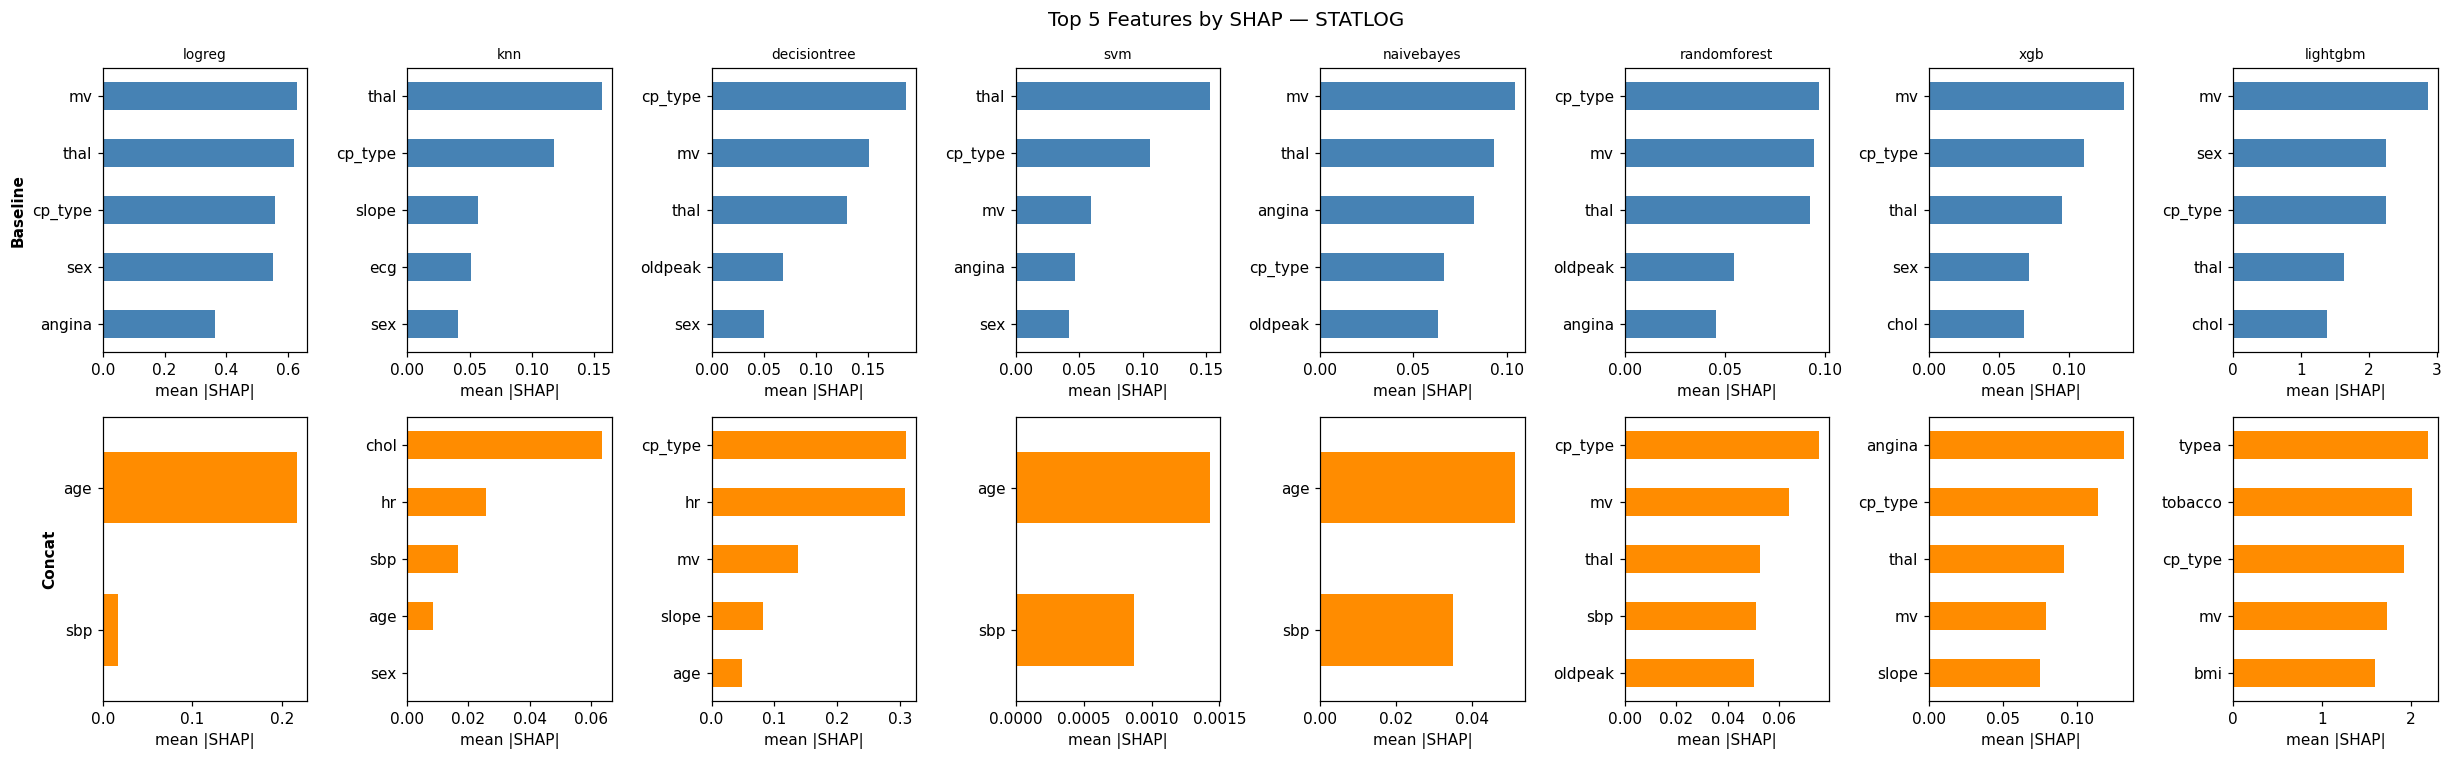

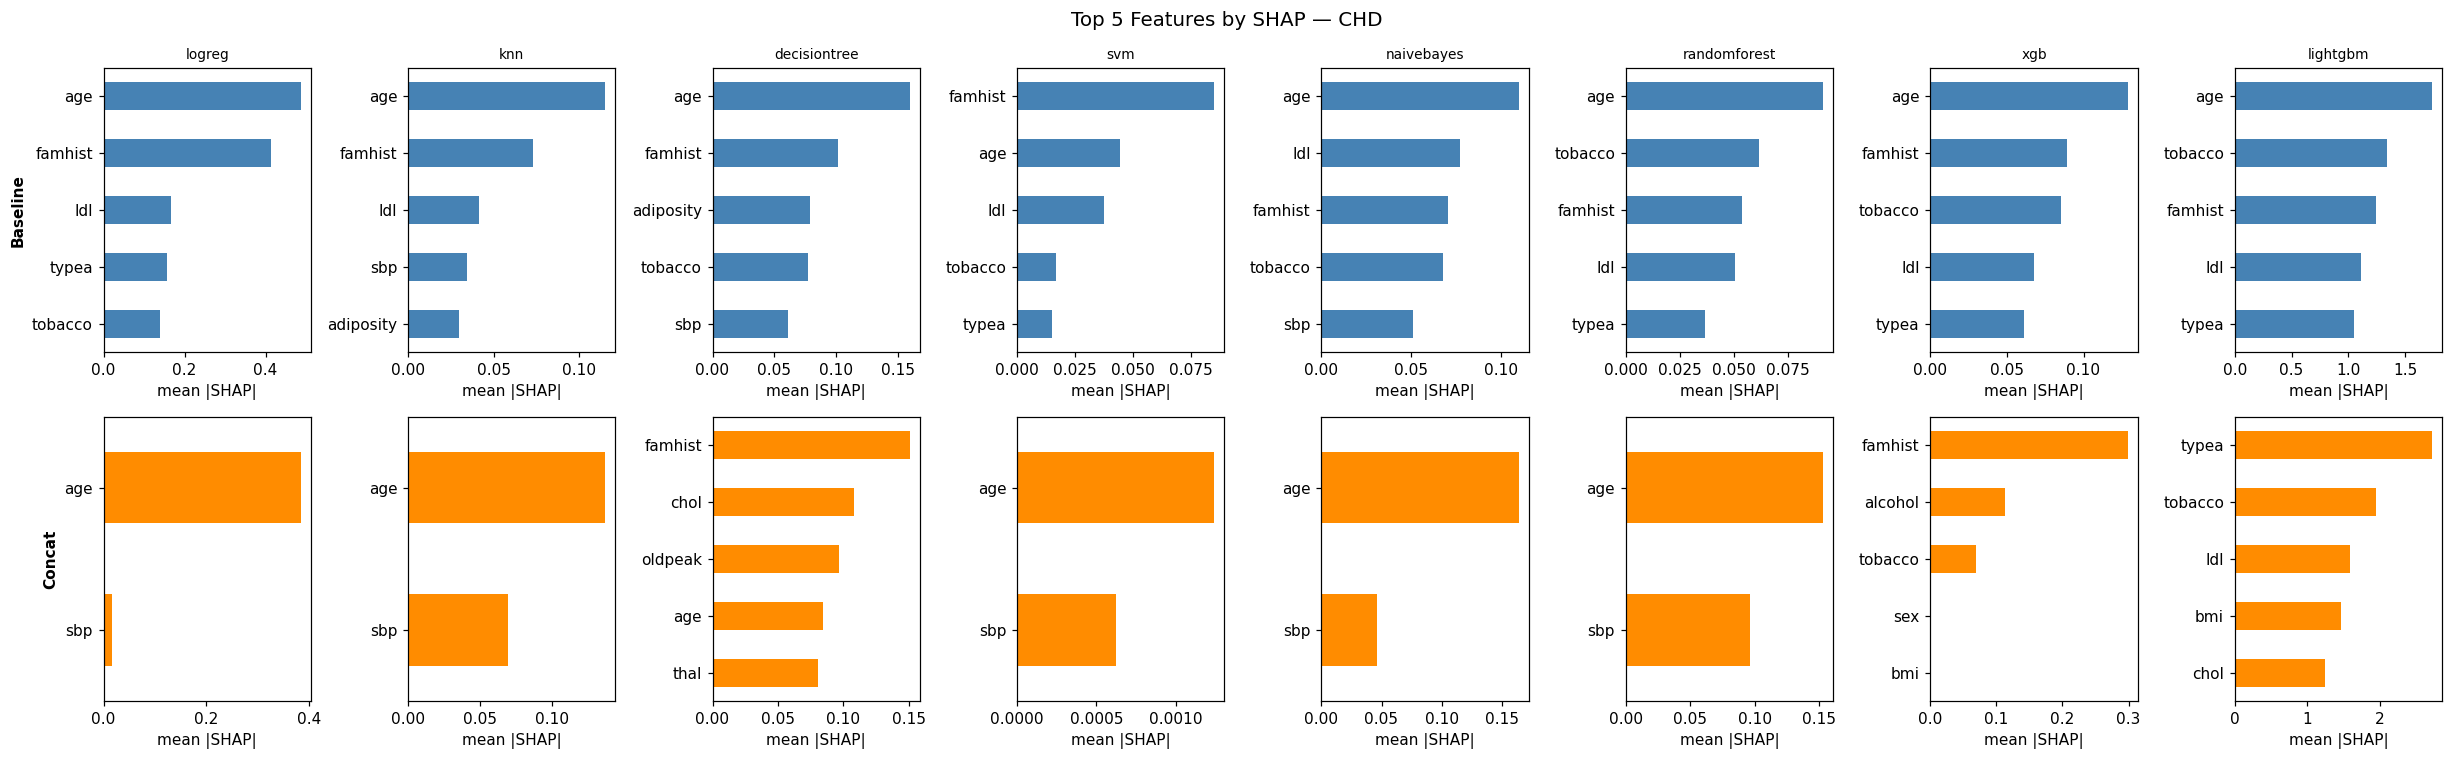

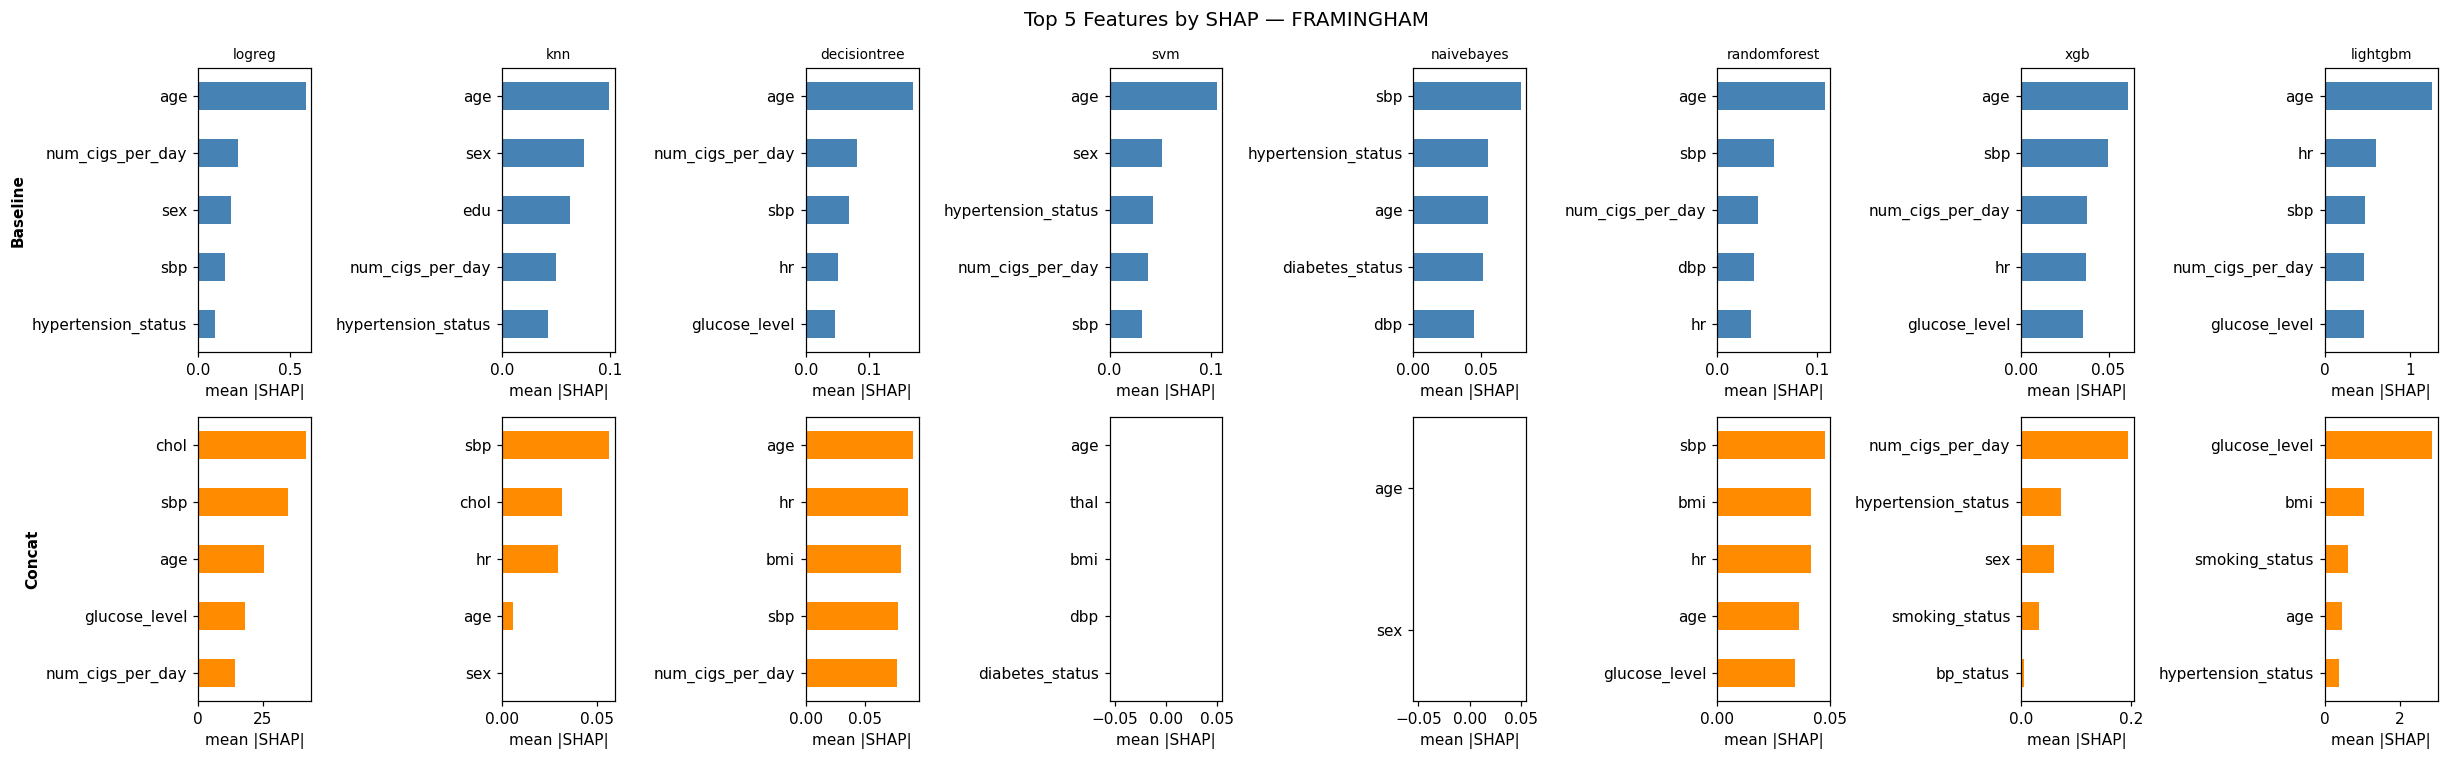

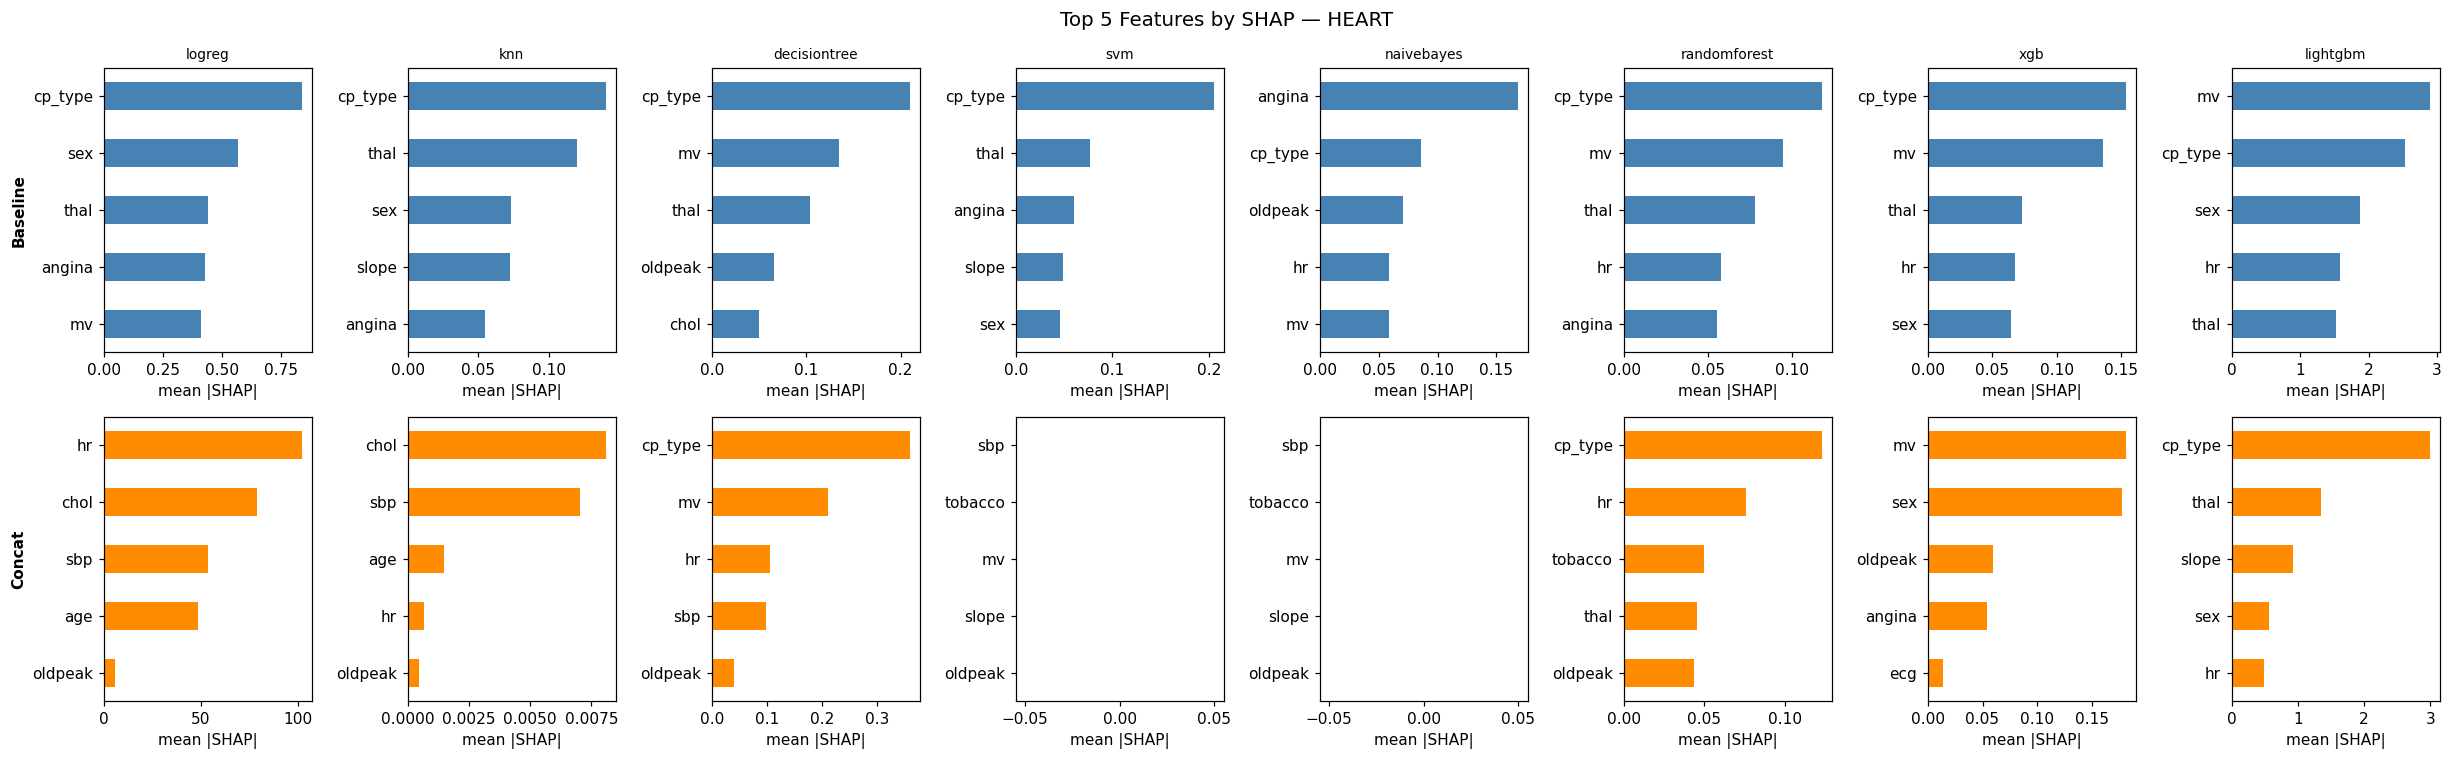

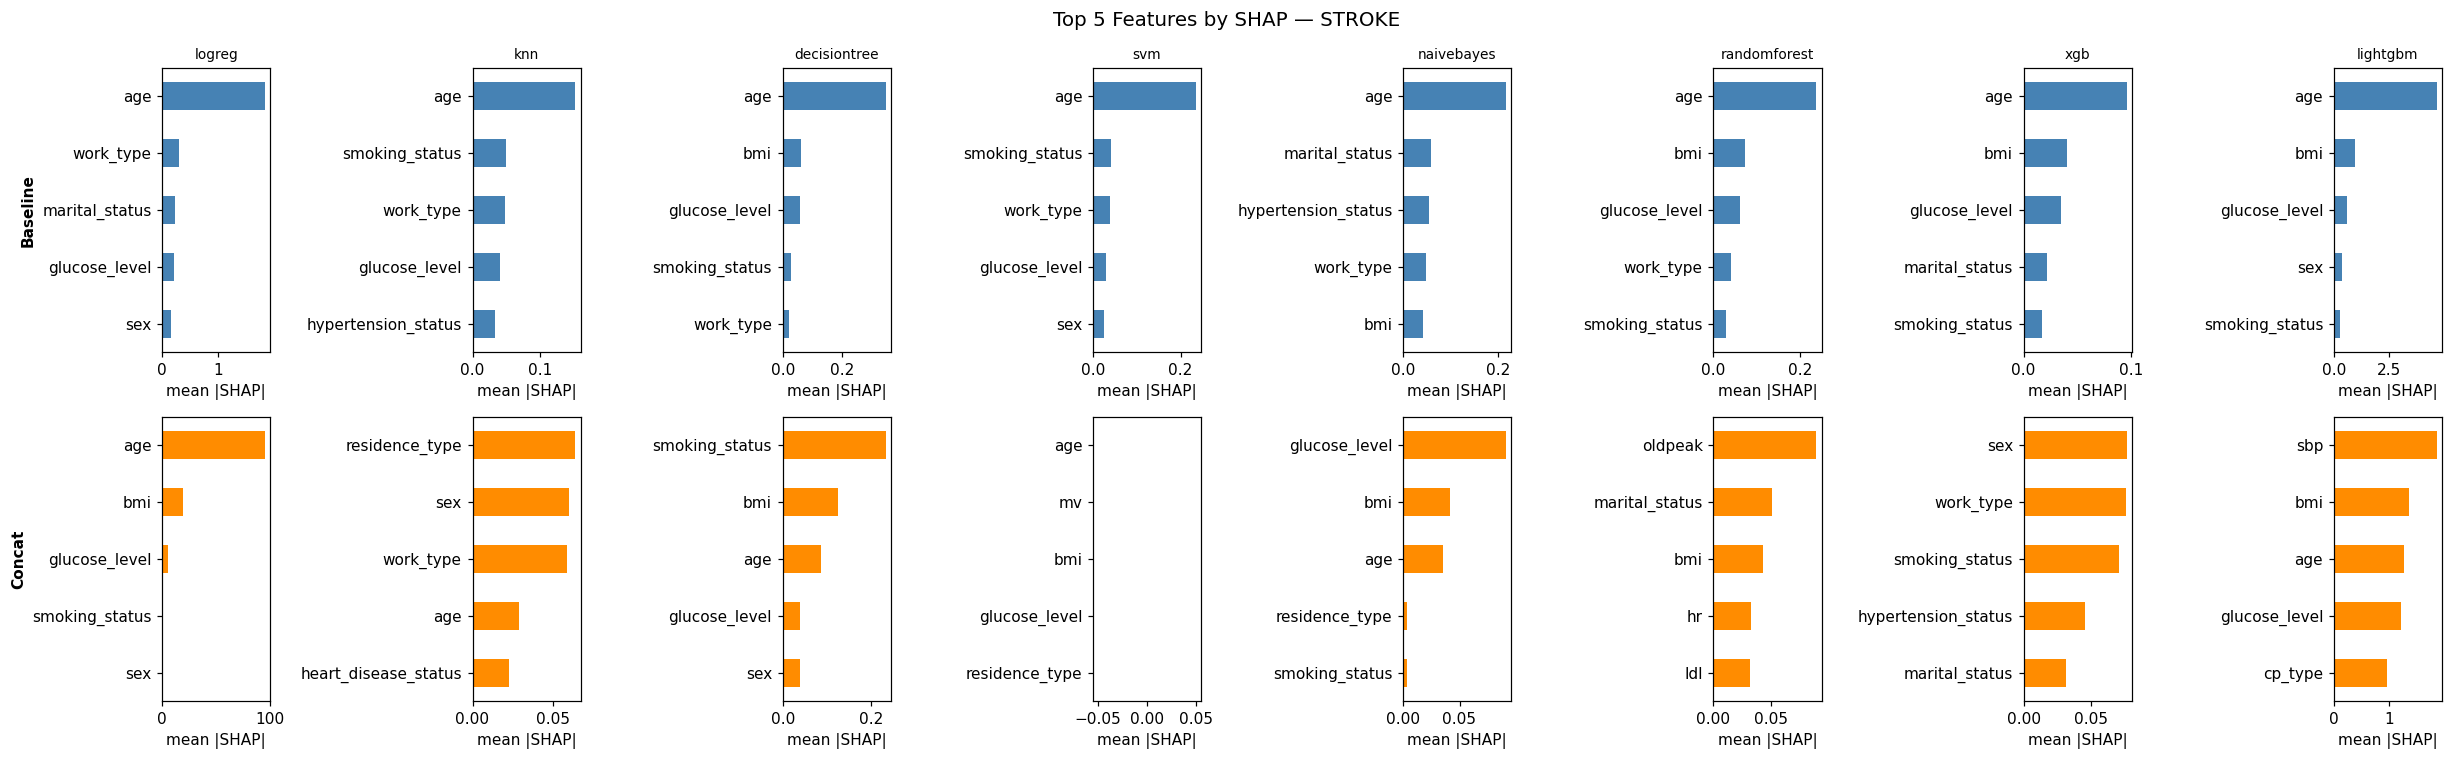

In [5]:
for ds in DATASETS:
    n_models = len(MODEL_NAMES)
    fig, axes = plt.subplots(2, n_models, figsize=(n_models * 2.8, 7),
                              sharey=False)

    for col, model_name in enumerate(MODEL_NAMES):
        base_imp = baseline_shap.get((ds, model_name))
        conc_imp = concat_shap.get((ds, model_name))

        for row, (imp, title) in enumerate([
            (base_imp, 'Baseline'),
            (conc_imp, 'Concat')
        ]):
            ax = axes[row][col]
            if imp is not None:
                imp.plot(kind='barh', ax=ax, color='steelblue' if row == 0 else 'darkorange')
                ax.invert_yaxis()
                ax.set_xlabel('mean |SHAP|')
            else:
                ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                        transform=ax.transAxes)
                ax.axis('off')

            if row == 0:
                ax.set_title(model_name, fontsize=9)
            if col == 0:
                ax.set_ylabel(title, fontsize=10, fontweight='bold')
            else:
                ax.set_ylabel('')

    fig.suptitle(f'Top {TOP_N} Features by SHAP — {ds.upper()}', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'result/images/shap_{ds}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print()

## SHAP Table Export

In [6]:
rows = []
for (ds, model_name), imp in baseline_shap.items():
    if imp is not None:
        for rank, (feat, val) in enumerate(imp.items(), 1):
            rows.append({'dataset': ds, 'model': model_name, 'source': 'baseline',
                         'rank': rank, 'feature': feat, 'mean_abs_shap': val})

for (ds, model_name), imp in concat_shap.items():
    if imp is not None:
        for rank, (feat, val) in enumerate(imp.items(), 1):
            rows.append({'dataset': ds, 'model': model_name, 'source': 'concat',
                         'rank': rank, 'feature': feat, 'mean_abs_shap': val})

df_shap = pd.DataFrame(rows)
df_shap.to_csv('result/shap_importance.csv', index=False)
df_shap.head(10)

,dataset,model,source,rank,feature,mean_abs_shap
0,statlog,logreg,baseline,1,mv,0.630178
1,statlog,logreg,baseline,2,thal,0.618159
2,statlog,logreg,baseline,3,cp_type,0.556048
3,statlog,logreg,baseline,4,sex,0.552557
4,statlog,logreg,baseline,5,angina,0.361461
5,statlog,knn,baseline,1,thal,0.156114
6,statlog,knn,baseline,2,cp_type,0.117428
7,statlog,knn,baseline,3,slope,0.056446
8,statlog,knn,baseline,4,ecg,0.051193
9,statlog,knn,baseline,5,sex,0.040932
